<a href="https://colab.research.google.com/github/Syedakhunza/machine-learning-09/blob/main/Copy_of_Untitled14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
df_train = pd.read_csv('/content/fraudTrain.csv')

# Loading the testting data
df_test = pd.read_csv('/content/fraudTest.csv')

In [ ]:
df_train

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116616,116616,2019-03-07 05:06:31,36078114201167,fraud_Mraz-Herzog,gas_transport,63.88,Christopher,Horn,M,956 Sanchez Highway,...,37.2692,-82.9161,798,Facilities manager,1926-06-26,5623283e1ed091c1cc5977c73bd0e0e2,1.331097e+09,37.388709,-83.754013,0.0
116617,116617,2019-03-07 05:09:57,6526448584969862,fraud_Deckow-O'Conner,grocery_pos,105.52,Nathan,Stewart,M,63502 Brown Road Apt. 318,...,40.2878,-74.0162,8097,Mechanical engineer,1964-02-18,c47d3142af1c8a6389a0566477d697b2,1.331097e+09,40.107008,-74.254615,0.0
116618,116618,2019-03-07 05:10:08,4092452671396169678,fraud_Kling Inc,gas_transport,45.48,Jeffrey,Vargas,M,478 Alexandria Mount,...,34.3091,-78.3372,2290,"Engineer, biomedical",1945-12-07,35d7019344b6ec0c87c76558184fda70,1.331097e+09,33.826334,-79.320000,0.0
116619,116619,2019-03-07 05:12:28,639095706599,fraud_Goyette Inc,shopping_net,16.84,Kyle,Wilkinson,M,93970 Trujillo Causeway,...,42.9633,-94.7975,223,Estate manager/land agent,1939-04-14,3d8b34ae09cebbbd583653b4a4ce4272,1.331097e+09,42.114731,-95.177616,0.0


In [ ]:
df_test

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2.291164e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497.0,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1.371817e+09,33.986391,-81.200714,0.0
1,1,2020-06-21 12:14:33,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302.0,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1.371817e+09,39.450498,-109.960431,0.0
2,2,2020-06-21 12:14:53,3.598215e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496.0,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1.371817e+09,40.495810,-74.196111,0.0
3,3,2020-06-21 12:15:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767.0,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1.371817e+09,28.812398,-80.883061,0.0
4,4,2020-06-21 12:15:17,3.526826e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126.0,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1.371817e+09,44.959148,-85.884734,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128195,128195,2020-08-04 16:58:40,3.512365e+15,fraud_Kuphal-Predovic,misc_net,257.39,Francisco,Kemp,M,9554 Flores Drive,...,38.4305,-90.3870,35439.0,Land/geomatics surveyor,1985-03-31,8c1767ada6f7bb260cebf62b0ef891bc,1.375636e+09,37.431114,-89.616074,0.0
128196,128196,2020-08-04 16:59:41,3.531130e+15,"fraud_Langworth, Boehm and Gulgowski",shopping_net,3.14,Shelby,Mitchell,F,974 Cindy Stream,...,43.8065,-73.0882,5895.0,"Scientist, marine",1975-07-13,a683300a2ebbece9f1e4ad8804b5a5c0,1.375636e+09,44.280838,-72.827635,0.0
128197,128197,2020-08-04 17:00:14,3.547560e+15,fraud_Quitzon-Goyette,home,60.64,Jerry,Robinson,M,212 Mary Stream,...,44.5232,-86.2061,680.0,"Designer, jewellery",1966-12-21,1c3aa5c149384eced264a6a595074bde,1.375636e+09,44.738534,-85.463196,0.0
128198,128198,2020-08-04 17:00:23,4.981133e+12,fraud_Labadie LLC,personal_care,87.58,Joseph,Spencer,M,7854 Stephanie Island Suite 788,...,40.0113,-80.9701,128.0,Child psychotherapist,1946-04-03,78b149faa6c91de65952ee92dc0b7934,1.375636e+09,41.000243,-81.673773,0.0


In [ ]:
print(f"\nShape of Training Data: {df_train.shape}")
print(f"Shape of Testing Data:  {df_test.shape}")


Shape of Training Data: (116621, 23)
Shape of Testing Data:  (128200, 23)


In [ ]:
print("\n--- First 5 Rows of Training Data ---")
display(df_train.head())


--- First 5 Rows of Training Data ---


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


In [ ]:
print("\n--- Data Info (Types & Missing Values) ---")
df_train.info()


--- Data Info (Types & Missing Values) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116621 entries, 0 to 116620
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             116621 non-null  int64  
 1   trans_date_trans_time  116621 non-null  object 
 2   cc_num                 116621 non-null  int64  
 3   merchant               116621 non-null  object 
 4   category               116621 non-null  object 
 5   amt                    116621 non-null  float64
 6   first                  116621 non-null  object 
 7   last                   116621 non-null  object 
 8   gender                 116621 non-null  object 
 9   street                 116621 non-null  object 
 10  city                   116621 non-null  object 
 11  state                  116621 non-null  object 
 12  zip                    116621 non-null  int64  
 13  lat                    116621 non-null  float

In [ ]:
duplicates = df_train.duplicated().sum()
print(f"\n--- Duplicate Rows: {duplicates} ---")


--- Duplicate Rows: 0 ---


In [ ]:
print("\n--- Unique Values per Column ---")
print(df_train.nunique())


--- Unique Values per Column ---
Unnamed: 0               116621
trans_date_trans_time    115177
cc_num                      922
merchant                    693
category                     14
amt                       22311
first                       341
last                        470
gender                        2
street                      922
city                        848
state                        50
zip                         911
lat                         909
long                        910
city_pop                    833
job                         479
dob                         908
trans_num                116621
unix_time                115208
merch_lat                116217
merch_long               116462
is_fraud                      2
dtype: int64


In [ ]:
columns_to_drop = ['Unnamed: 0', 'trans_num']

df_train = df_train.drop(columns=columns_to_drop, errors='ignore')
df_test = df_test.drop(columns=columns_to_drop, errors='ignore')

print(f"New Shape of Training Data: {df_train.shape}")

New Shape of Training Data: (116621, 21)


In [ ]:
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['dob'] = pd.to_datetime(df_train['dob'])

df_train['age'] = (df_train['trans_date_trans_time'] - df_train['dob']).dt.days // 365

# B. Extracting hours,weekdays,days,month and year
df_train['hour'] = df_train['trans_date_trans_time'].dt.hour
df_train['weekday'] = df_train['trans_date_trans_time'].dt.weekday
df_train['day'] = df_train['trans_date_trans_time'].dt.day
df_train['month'] = df_train['trans_date_trans_time'].dt.month

display(df_train.head())

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,dob,unix_time,merch_lat,merch_long,is_fraud,age,hour,weekday,day,month
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,1988-03-09,1.325376e+09,36.011293,-82.048315,0.0,30,0,1,1,1
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,1978-06-21,1.325376e+09,49.159047,-118.186462,0.0,40,0,1,1,1
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,1962-01-19,1.325376e+09,43.150704,-112.154481,0.0,56,0,1,1,1
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,1967-01-12,1.325376e+09,47.034331,-112.561071,0.0,52,0,1,1,1
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,1986-03-28,1.325376e+09,38.674999,-78.632459,0.0,32,0,1,1,1


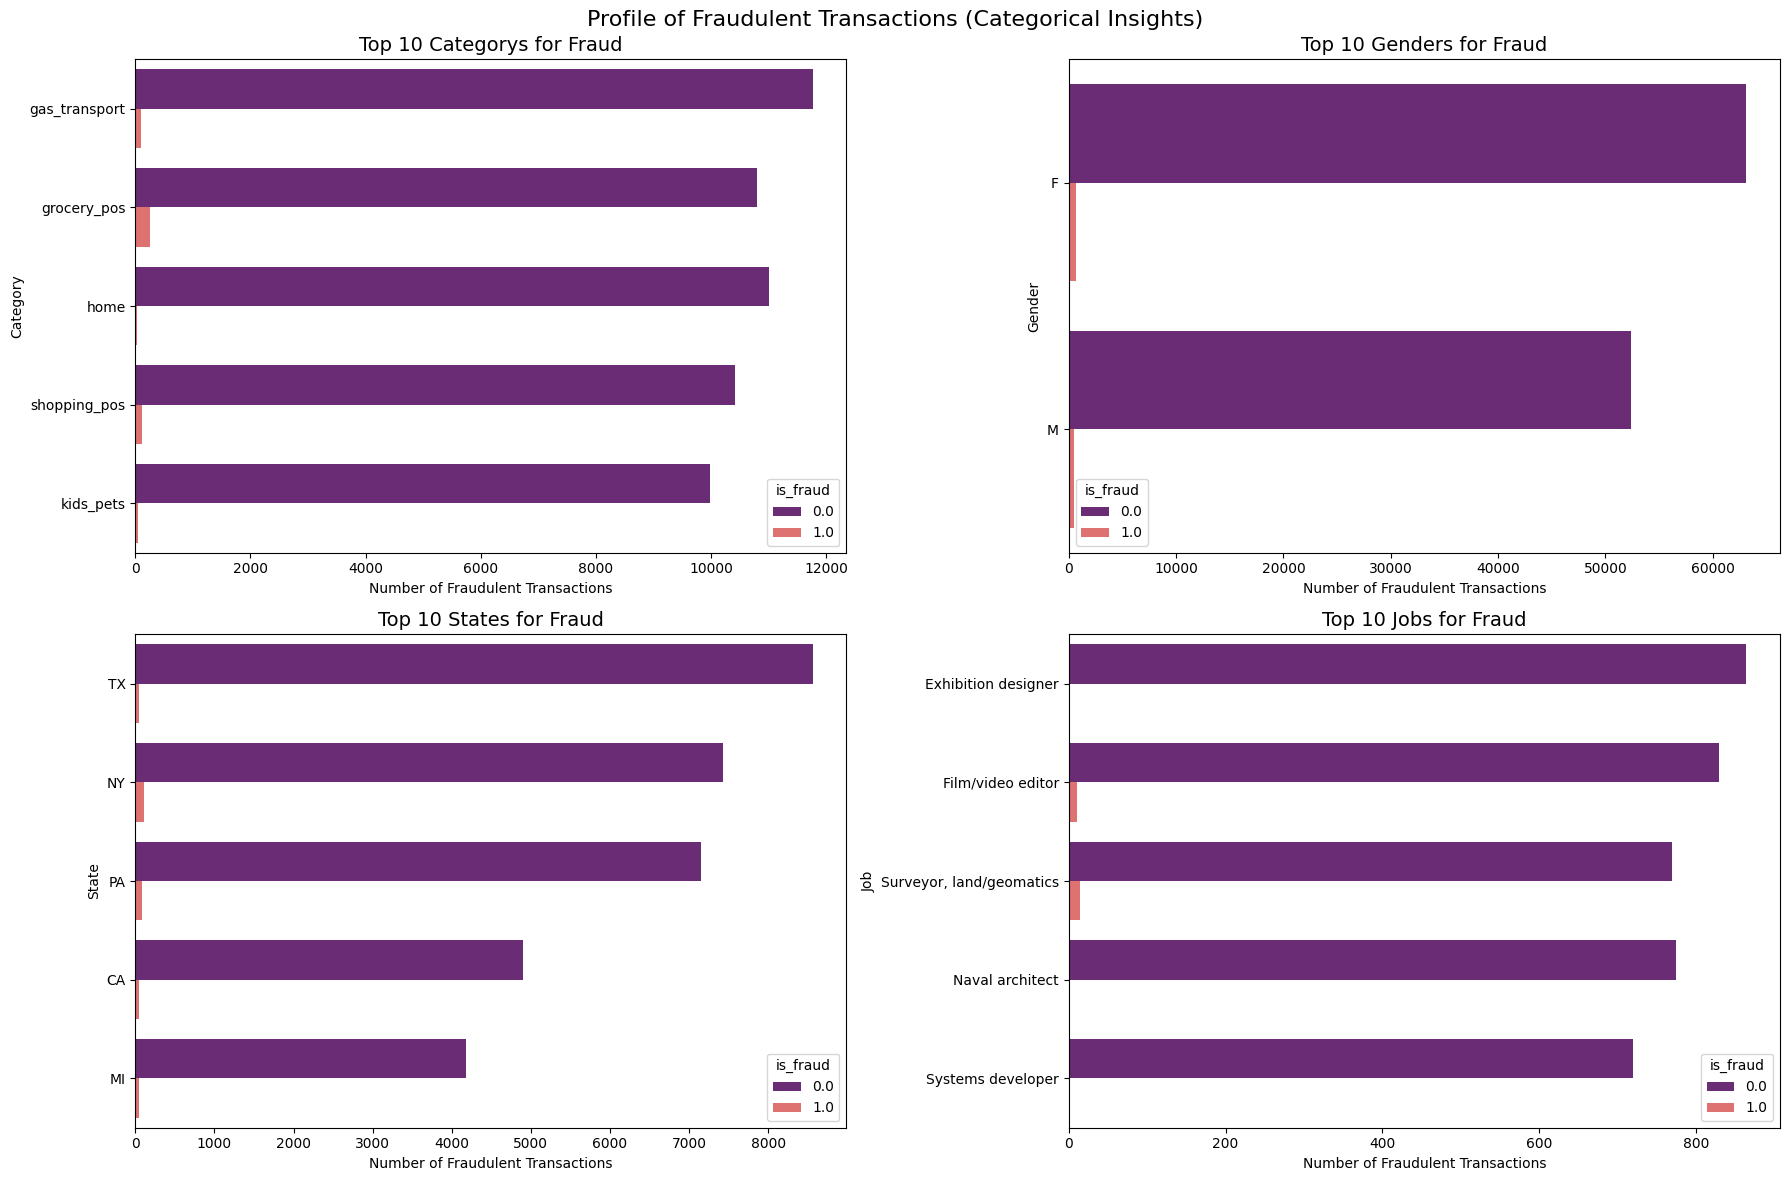

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


categorical_cols = ['category', 'gender', 'state', 'job']

plt.figure(figsize=(18, 12))
plt.suptitle('Profile of Fraudulent Transactions (Categorical Insights)', fontsize=16)

# 4. Loop through columns and create plots
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    top_counts = df_train[col].value_counts().nlargest(5).index

    # Create Bar Plot
    sns.countplot(y=col, data=df_train,hue='is_fraud',order=top_counts,palette='magma')

    plt.title(f'Top 10 {col.title()}s for Fraud', fontsize=14)
    plt.xlabel('Number of Fraudulent Transactions')
    plt.ylabel(col.title())

plt.tight_layout()
plt.show()



/tmp/ipykernel_12838/3790721067.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot( y=col, data=df_train, palette='coolwarm')
/tmp/ipykernel_12838/3790721067.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot( y=col, data=df_train, palette='coolwarm')
/tmp/ipykernel_12838/3790721067.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot( y=col, data=df_train, palette='coolwarm')
/tmp/ipykernel_12838/3790721067.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` vari

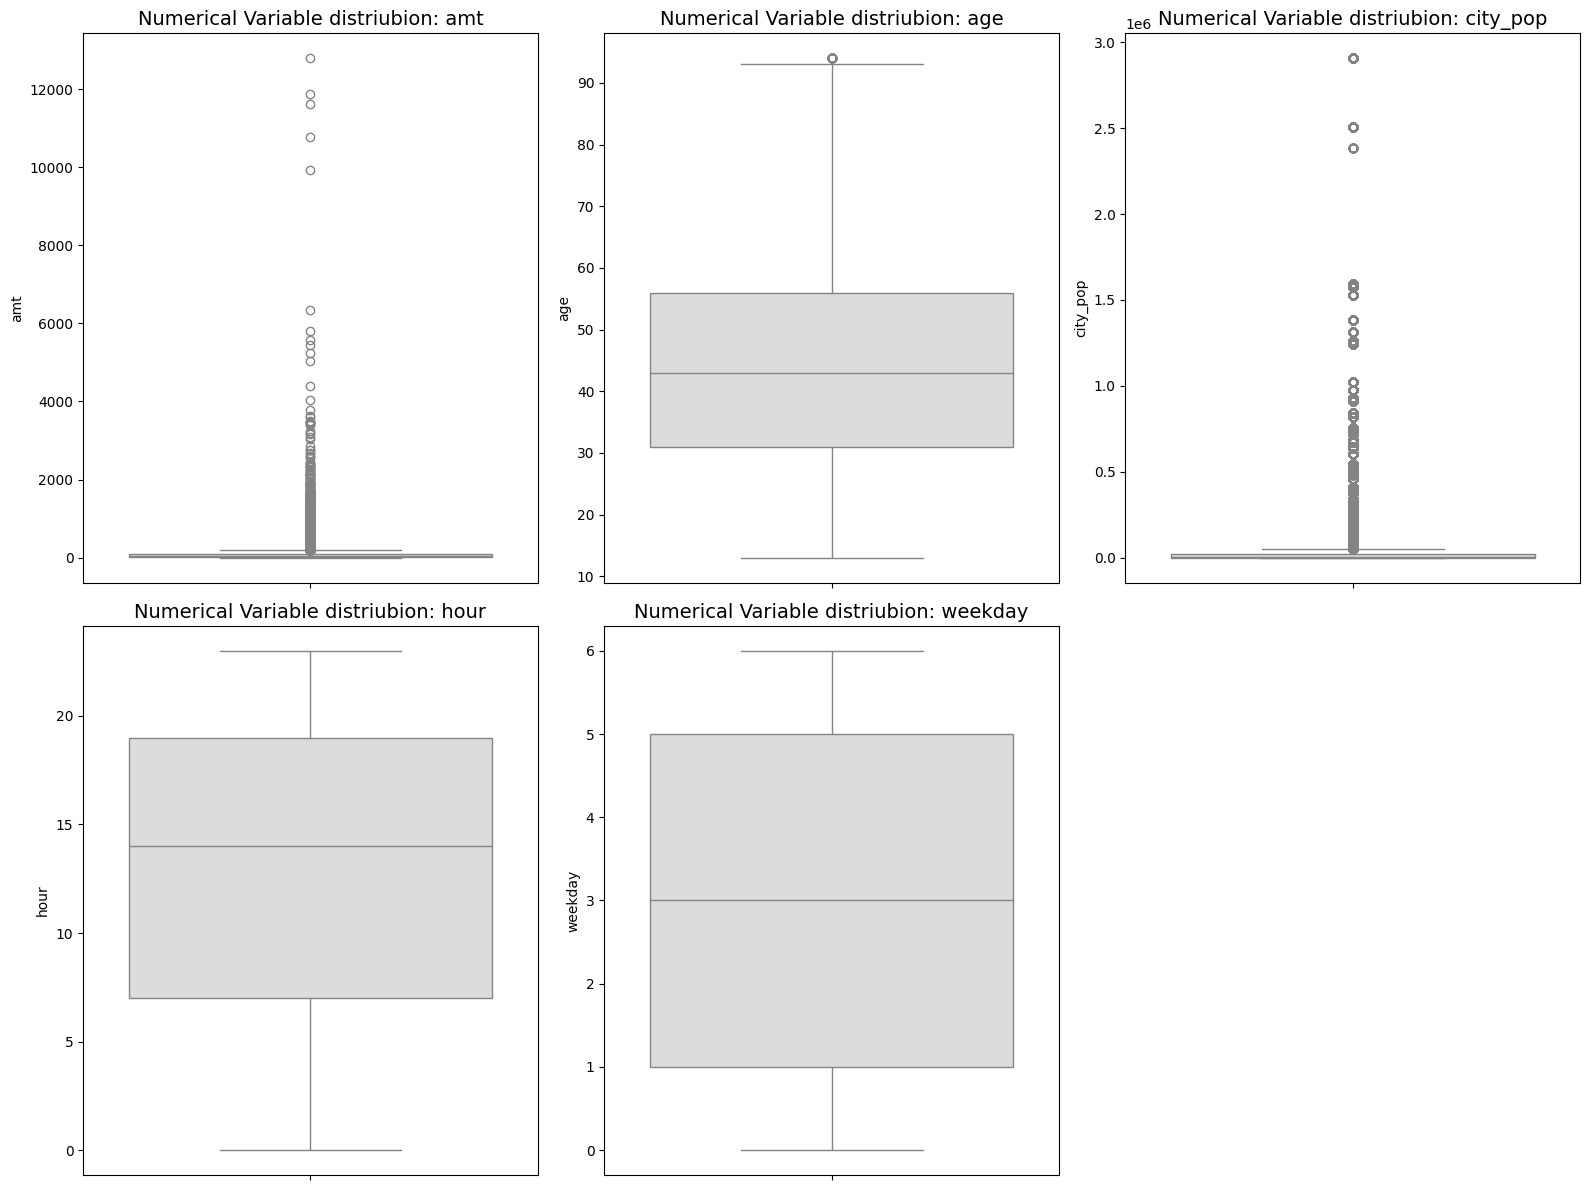

In [ ]:
numerical_cols = ['amt', 'age', 'city_pop', 'hour','weekday']

plt.figure(figsize=(16, 12))

# Loop through the columns and create a plot for each
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)

    # Use a Box Plot to compare distributions
    # This shows the Median (middle line) and Outliers (dots)
    sns.boxplot( y=col, data=df_train, palette='coolwarm')

    plt.title(f'Numerical Variable distriubion: {col}', fontsize=14)
    plt.tight_layout()
plt.show()

--- STATUS: Calculating Correlations... ---

--- Top Features Correlated with Fraud ---
is_fraud      1.000000
amt           0.285517
day           0.015163
hour          0.012722
lat           0.012381
merch_lat     0.012091
age           0.008928
city_pop      0.008655
long          0.004469
merch_long    0.004442
unix_time    -0.001476
weekday      -0.006537
zip          -0.007699
cc_num       -0.008151
month        -0.008468
Name: is_fraud, dtype: float64


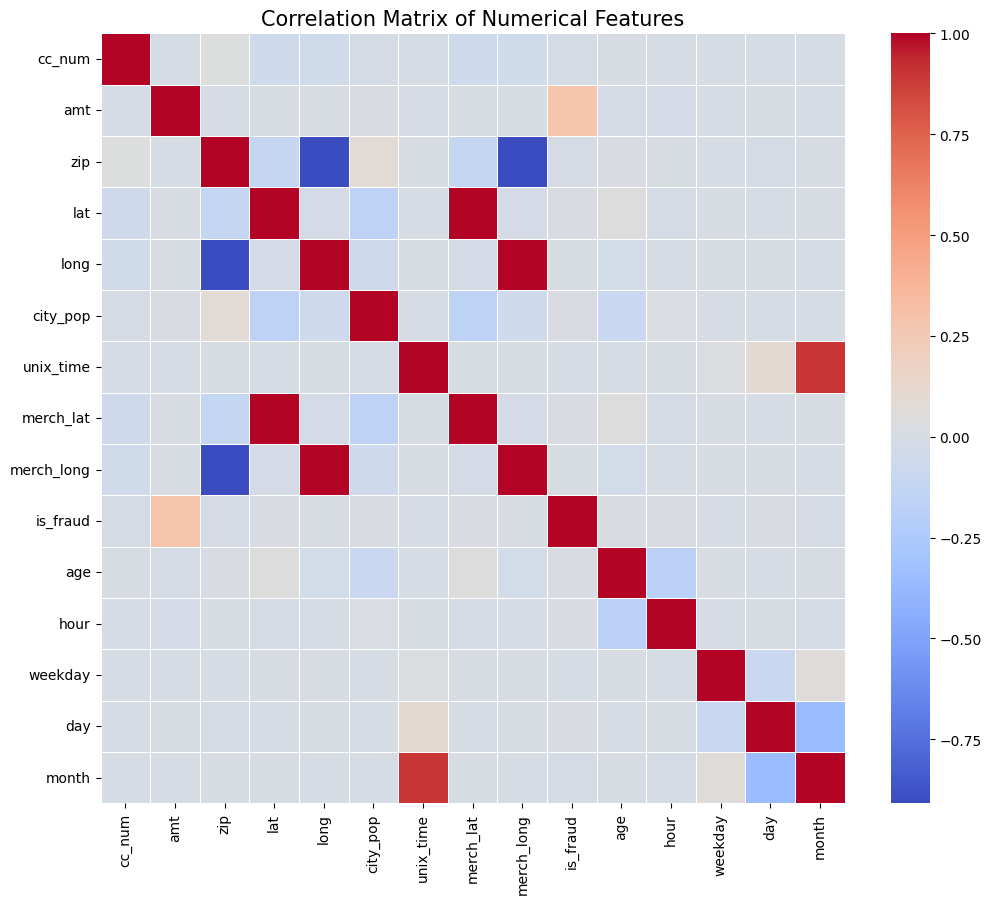

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- STATUS: Calculating Correlations... ---")

# 1. Selecting only numerical columns
numeric_df = df_train.select_dtypes(include=[np.number])

# 2. Calculating Correlation Matrix
corr_matrix = numeric_df.corr()
fraud_correlation = corr_matrix['is_fraud'].sort_values(ascending=False)
print("\n--- Top Features Correlated with Fraud ---")
print(fraud_correlation)

# VISUALIZATION: THE HEATMAP
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=15)
plt.show()